# Hypothesis Testing
This notebook documents the statistical analysis performed for this project. I will evaluate three hypotheses to determine if perceived gameplay trends are backed by data.

## Hypothesis 1: Are Water types bulkier, or is Suicune gaslighting us?
---
**Motivation**

Historically, bulky Water types have performed exceptionally well in competitive Pokémon; specifically, **Suicune** was a mainstay in multiple generations. Because of this, there is a common perception of Water as a bulky type. This however, is an assumption made based on the performance of a few. Thus I wanted to test this assumption through the application of statistical methods.

**Scope**

There are two primary factors contributing to the survivability of a Pokémon: the defensive properties of its **typing** and its defensive **base stats** (HP, Defense, Special Defense).

* **Typing Complexity:** Water is a strong defensive type (2 weaknesses, 4 resistances). However, its contribution to bulk is difficult to generalize for dual-type Pokémon.
    * **Water/Rock:** 4 weaknesses (including a double weaknesses) and 5 resistances (including a double resistance).
    * **Water/Dragon:** 2 weaknesses and 3 resistances (including 2 double resistances).

  *Note: Weakness (x2 damage), double weakness (x4 damage), resistance (x0.5 damage) and double resistance (x0.25 damage)*
* **Data Constraints:** Out of 183 Water-type Pokémon, only 84 are mono-Water. Because dual-typing introduces too much variability, the defensive properties of typing will not be considered in this hypothesis.

**Approach**

Which leaves us with defensive stats, for this project bulk will be quantified as the percentage of a Pokémon's **Base Stat Total (BST)** allocated to defensive stats.

The formula for **Bulk** is defined as:

$$Bulk = \frac{HP + Defense + Sp. Defense}{BST}$$

**Question:** Is the bulk distribution of Water-type Pokémon significantly different from the bulk distribution of Pokémon of other types?

**Null Hypothesis:** There is no statistically significant difference between the bulk distribution of non-Water type Pokémon and Water type Pokémon.

**Alternative Hypothesis:** Water types have a statistically significant bulk lead over Pokémon of other types.

---

In [1]:
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns

project_data_path = '../data'

In [2]:
with open(os.path.join(project_data_path, 'pokemon.json'), 'r', encoding='utf-8') as f:
    pokemon = json.load(f)

In [3]:
counter_mono = 0
counter_all = 0
for pkmn, details in pokemon.items():

    types = details.get('types', [])

    if len(types) == 1 and types[0]['type']['name'] == "water":
        counter_mono += 1
        counter_all += 1
    elif len(types) == 2 and (types[0]['type']['name'] == "water" or types[1]['type']['name'] == "water"):
        counter_all += 1

print(f"Mono-water types: {counter_mono}, All water types: {counter_all}")

Mono-water types: 84, All water types: 183


In [4]:
import pandas as pd
from scipy import stats

excluded_forms = ['-gmax']

bulk_array = []
off_gap_array = []

for name, details in pokemon.items():
    skip = False
    for keyword in excluded_forms:
      if(keyword in name):
        skip = True
        break
    if(not skip):
      stats_dict = {s['stat']['name']: s['base_stat'] for s in details['stats']}

      # Calculate BST
      bst = sum(stats_dict.values())

      # Calculate Bulk Metric
      # Bulk = (HP + Defense + Sp. Defense) / BST
      bulk = (stats_dict['hp'] + stats_dict['defense'] + stats_dict['special-defense']) / bst

      types = [t['type']['name'] for t in details['types']]
      is_water = 'water' in types

      bulk_array.append({'name': name, 'bulk': bulk, 'is_water': is_water})

      # Calculate Offensive Gap Metric
      # Offensive Gap = absolute_value(Attack - Special Attack)
      off_gap = abs(stats_dict['attack'] - stats_dict['special-attack'])

      if(details['generation'] < 4):
        pre_gen4 = True
      else:
        pre_gen4 = False

      off_gap_array.append({'name': name, 'off_gap': off_gap, 'pre_gen4': pre_gen4})


df_bulk = pd.DataFrame(bulk_array)
df_off_gap = pd.DataFrame(off_gap_array)
print(df_off_gap)

                      name  off_gap  pre_gen4
0                bulbasaur       16      True
1                  ivysaur       18      True
2                 venusaur       18      True
3               charmander        8      True
4               charmeleon       16      True
...                    ...      ...       ...
1244          zeraora-mega       10     False
1245       scovillain-mega        0     False
1246         glimmora-mega       60     False
1247  tatsugiri-curly-mega       70     False
1248       baxcalibur-mega       70     False

[1249 rows x 3 columns]


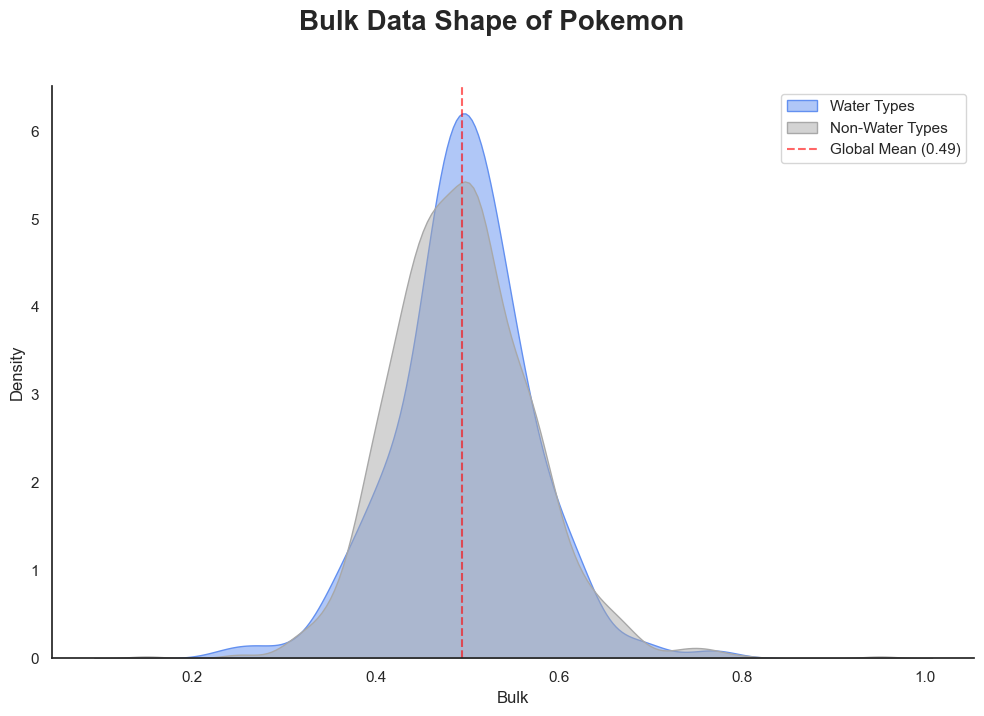

In [5]:
sns.set_theme(style="white")

# 1. Setup the figure
plt.figure(figsize=(10, 7))

# Define colors: Water Blue vs a Neutral Gray for others
palette = {True: "#6390F0", False: "#A8A8A8"}
labels = {True: "Water Types", False: "Non-Water Types"}

# --- Plot 1: KDE Distribution (The "Overlap" View) ---
for is_water in [True, False]:
    subset = df_bulk[df_bulk['is_water'] == is_water]
    sns.kdeplot(subset['bulk'], fill=True,
                color=palette[is_water], label=labels[is_water], alpha=0.5)


global_mean = df_bulk['bulk'].mean()
plt.axvline(global_mean, color='red', linestyle='--', alpha=0.6, label=f'Global Mean ({global_mean:.2f})')

plt.xlabel("Bulk")
plt.legend()

plt.suptitle("Bulk Data Shape of Pokemon", fontsize=20, y=1.02, fontweight="bold")
plt.tight_layout()
sns.despine() # Remove top and right spines
plt.show()

## KDE Plot Analysis
A KDE plot was drawn to visualize the bulk distributions. The visuals suggest both Water and non-Water types bulks are normally distributed and there isn't a meaningful difference between the two. The global mean is 0.49 suggesting the majority of Pokémon's stats are well balanced between offense and defense.

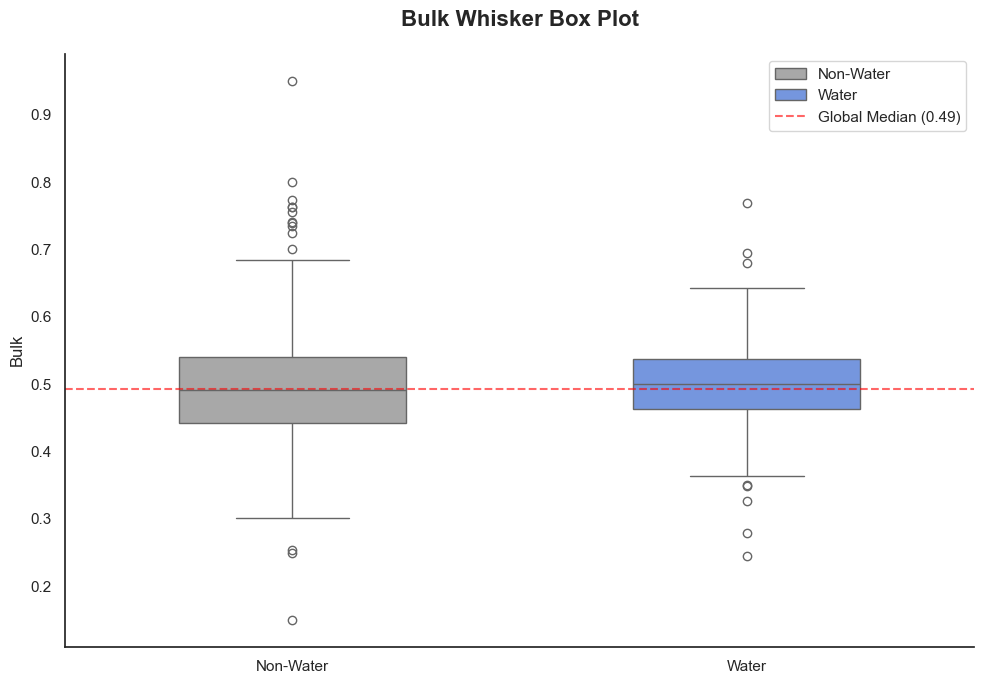

In [6]:
# 1. Prepare data (mapping booleans to strings to avoid palette errors)
plot_df = df_bulk.copy()
plot_df['Type Category'] = plot_df['is_water'].map({True: 'Water', False: 'Non-Water'})

# 2. Define colors
palette = {'Water': "#6390F0", 'Non-Water': "#A8A8A8"}

# 3. Setup the plot
plt.figure(figsize=(10, 7))

# Create the box plot
sns.boxplot(
    data=plot_df,
    x='Type Category',
    y='bulk',
    palette=palette,
    width=0.5,
    hue='Type Category',
    legend=True
)

global_median = df_bulk['bulk'].median()
plt.axhline(global_median, color='red', linestyle='--', alpha=0.6, label=f'Global Median ({global_median:.2f})')

# Formatting
plt.title("Bulk Whisker Box Plot", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Bulk", fontsize=12)
plt.xlabel("")
plt.legend(loc='upper right')

sns.despine() # Makes it look modern
plt.tight_layout()
plt.show()

## Box and Whisker Plot Analysis
To take a better look at how the data is spread, a whisker box plot was drawn. Again the alternative hypothesis is visually unsupported. Interestingly the global mean and median are equal suggesting an equal pull by outliers in both directions, thus neutralizing the effect of each other. There are significantly more outliers in the non-Water category because the category is significantly more crowded.

# Independent Samples T-Test

The independent samples t-test was chosen because I am comparing the means of two normally distributed populations.

---

### **Variance Check & Test Version Selection**
Before performing the test, the variance of both distributions was checked to determine the appropriate method (Standard vs. Welch's T-Test).

| Population | Variance |
| :--- | :--- |
| **Water Types** | 0.0053 |
| **Non-Water Types** | 0.0059 |

The variances are nearly equal and the hypothesis claims that Water types have *greater* bulk. As such, a **One Sided Standard Independent Samples T-Test** is used.

---

### **Hypotheses**

**Null Hypothesis ($H_0$):** The mean bulk of Water types is equal to the mean Bulk % of other Pokémon types.
$$H_0: \mu_{water} = \mu_{other}$$

**Alternative Hypothesis ($H_1$):** The mean bulk of Water types is greater than the mean bulk of other Pokémon types.
$$H_1: \mu_{water} > \mu_{other}$$

### **Results**

Turns out Suicune does indeed warp my perception. The calculated p-value is **0.3412** with a significance level of **0.05** we fail to reject the null hypothesis. Thus it can be concluded, Water types do not have a statistically significant bulk advantage over other types.

In [7]:
water_bulk = df_bulk[df_bulk['is_water'] == True]['bulk']
non_water_bulk = df_bulk[df_bulk['is_water'] == False]['bulk']

print(f"Water types bulk variance: {water_bulk.var():.4f}")
print(f"Non-water types bulk variance: {non_water_bulk.var():.4f}")
# Checking the variance of each group to decide on the equal_var= parameter of ttest_ind

Water types bulk variance: 0.0053
Non-water types bulk variance: 0.0059


In [8]:
# One-sided T-Test (Alternative: Water > Non-Water)
# T-Test is chosen because I am comparing the means of two populations and my data is close to normally distributed
t_stat, p_val_t = stats.ttest_ind(water_bulk, non_water_bulk, alternative='greater')

print(f"T-test P-value: {p_val_t:.4f}")
if(p_val_t < 0.05):
  print(f"Null hypothesis rejected, water types are bulkier")
else:
  print(f"Failed to reject null hypothesis, water types do not have a statistically significant bulk advantage")

T-test P-value: 0.3397
Failed to reject null hypothesis, water types do not have a statistically significant bulk advantage


## Hypothesis 2: Did the Physical/Special split create a change in the way Pokémon are designed?
---
**Some Background and Motivation**

There are two types of damaging moves in Pokémon: **physical** and **special**. They are calculated using the attack and special attack stats, respectively. Until generation 4 a moves damage type depended on the moves type, for example all dark type moves were **special** while all fighting type moves were **physical**. Because of this Pokémon from the first 3 generations in general tend to have stat distributions considered weird by modern standards i.e. they do not specialize in one attacking stat instead they have mediocre stats in both. This is to ensure they can use attacks from their own type(s) decently well and to expand their options for moves from other types.

In generation 4 moves were split into physical and special instead of depending on their type, now every type had moves from both damage types. This I believe influenced the way Pokémon are designed as it allowed them to specialize in one attacking stat regardless of their type(s).

**Approach**

For this hypothesis I quantified the impact of the **physical/special** split as follows:

$${Offensive Gap} = |{Attack} - {Sp. Attack}|$$

**Question:** Do Pokémon from generation 4 onwards have a higher offensive gap in general?

**Null Hypothesis:** There is no statistically significant difference between the offensive gap distributions of pre and post generation 4 Pokémon.

**Alternative Hypothesis:** Pre generation 4 Pokémon have significantly lower offensive gap.

---

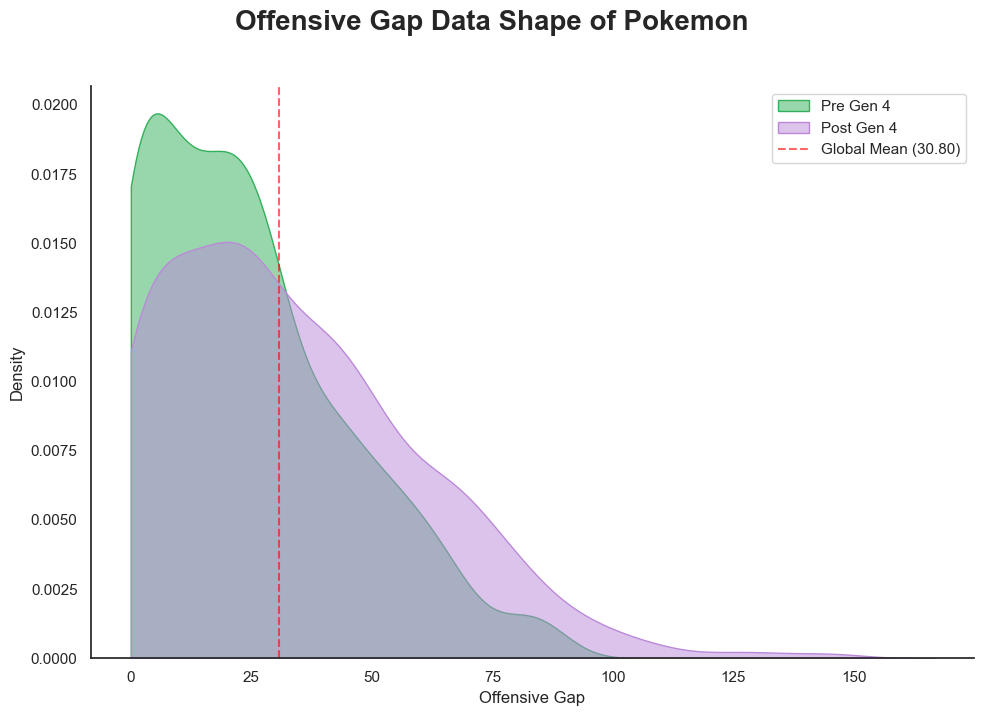

In [9]:
sns.set_theme(style="white")

# 1. Setup the figure
plt.figure(figsize=(10, 7))

palette = {True: "#33b05b", False: "#bb89d9"}
labels = {True: "Pre Gen 4", False: "Post Gen 4"}

# --- Plot 1: KDE Distribution (The "Overlap" View) ---
for pre_gen4 in [True, False]:
    subset = df_off_gap[df_off_gap['pre_gen4'] == pre_gen4]
    sns.kdeplot(subset['off_gap'], fill=True,
                color=palette[pre_gen4], label=labels[pre_gen4], alpha=0.5, clip=(0,None))


global_mean = df_off_gap['off_gap'].mean()
plt.axvline(global_mean, color='red', linestyle='--', alpha=0.6, label=f'Global Mean ({global_mean:.2f})')

plt.xlabel("Offensive Gap")
plt.legend()

plt.suptitle("Offensive Gap Data Shape of Pokemon", fontsize=20, y=1.02, fontweight="bold")
plt.tight_layout()
sns.despine() # Remove top and right spines
plt.show()

## KDE Plot Analysis
A KDE plot was drawn to visualize the offensive gap distributions. The visuals show right skewed distributions, this indicates a majority of Pokémon have relatively close attacking stats while the few with extreme specializations skew data. The alternative hypothesis is visually supported by the KDE plot as the post gen 4 distribution's highest frequency area (the peak of the hill) is closer to the center compared to pre gen 4 distribution.

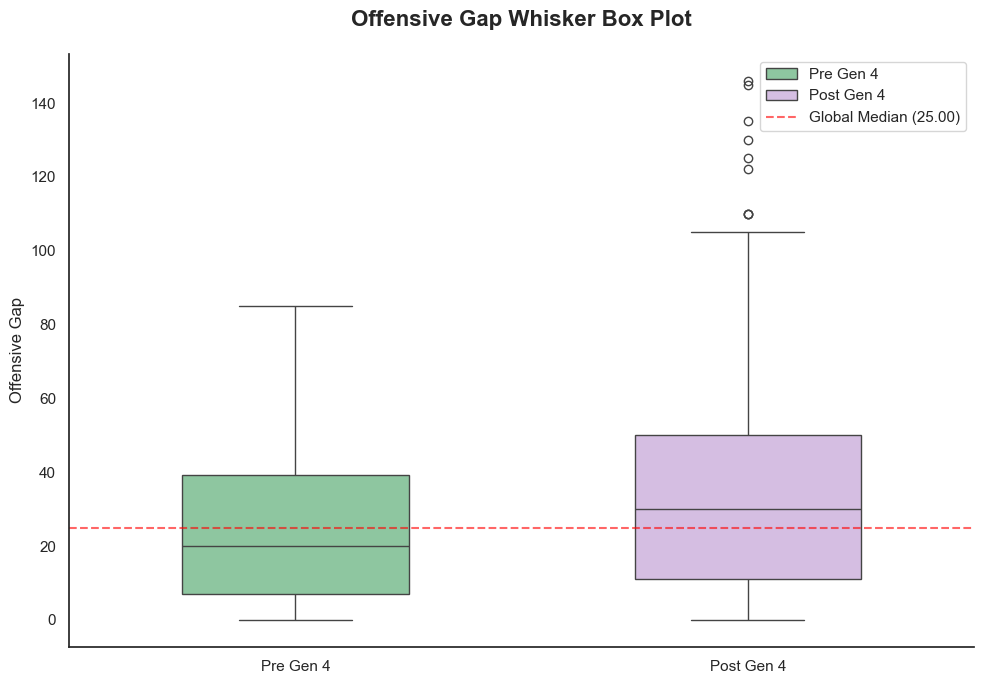

In [10]:
# 1. Prepare data (mapping booleans to strings to avoid palette errors)
plot_df = df_off_gap.copy()
plot_df['Type Category'] = plot_df['pre_gen4'].map({True: 'Pre Gen 4', False: 'Post Gen 4'})

# 2. Define colors
palette = {'Pre Gen 4': "#33b05b", 'Post Gen 4': "#bb89d9"}

# 3. Setup the plot
plt.figure(figsize=(10, 7))

# Create the box plot
ax = sns.boxplot(
    data=plot_df,
    x='Type Category',
    y='off_gap',
    palette=palette,
    width=0.5,
    hue='Type Category',
    legend=True
)

for patch in ax.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.6)) # Set alpha to 0.6

global_median = df_off_gap['off_gap'].median()
plt.axhline(global_median, color='red', linestyle='--', alpha=0.6, label=f'Global Median ({global_median:.2f})')

# Formatting
plt.title("Offensive Gap Whisker Box Plot", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Offensive Gap", fontsize=12)
plt.xlabel("")
plt.legend(loc='upper right')

sns.despine() # Makes it look modern
plt.tight_layout()
plt.show()

## Box and Whisker Plot Analysis
To take a better look at how the data is spread, a whisker box plot was drawn. Again the alternative hypothesis is visually supported. Pre gen 4 median is lower than the global median while post gen 4 median is higher. Pre gen 4 has no outliers suggesting no extreme specializations in the first 3 generations which supports my hypothesis that Pokémon were designed to have servicable attacking stats in both physical and special attack.

# Independent Samples T-Test

The independent samples t-test was chosen because I am comparing the means of two independent populations. The data is right skewed instead of normally distributed, since t-test assumes normal distribution a non-parametric test will also be used to verify the results of this test.

### **Variance Check & Test Version Selection**
Before performing the test, the variance of both distributions was checked to determine the appropriate method (Standard vs. Welch's T-Test).

| Population | Variance |
| :--- | :--- |
| **Pre-Gen 4** | 437.7588 |
| **Post-Gen 4** | 702.5510 |

There is a significant difference between the variances and the alternative hypothesis claims pre-gen 4 offensive gap is *lower*. As such, a **One Sided Independent Samples Welch's T-Test** is used.

---

### **Hypotheses**

**Null Hypothesis ($H_0$):** The mean offensive gap of pre-gen 4 Pokémon is equal to the mean offensive gap of post-gen 4 Pokémon.
$$H_0: \mu_{pre} = \mu_{post}$$

**Alternative Hypothesis ($H_1$):** The mean offensive gap of pre-gen 4 Pokémon is lower than the mean offensive gap of post-gen 4 Pokémon.
$$H_1: \mu_{pre} < \mu_{post}$$

### **Results**

The calculated p-value is **0.000000000008** with a significance level of **0.05** we safely reject the null hypothesis. According to Welch's t-test there is significant evidence to back up my intuition. Due to the skewed distribution a Mann-Whitney U test is performed to be sure.

In [11]:
pre_gen4_off_gap = df_off_gap[df_off_gap['pre_gen4'] == True]['off_gap']
post_gen4_off_gap = df_off_gap[df_off_gap['pre_gen4'] == False]['off_gap']

print(f"Pre gen 4 offensive gap variance: {pre_gen4_off_gap.var():.4f}")
print(f"Post gen 4 offensive gap variance: {post_gen4_off_gap.var():.4f}")
# Checking the variance of each group to decide on the equal_var= parameter of ttest_ind

Pre gen 4 offensive gap variance: 437.7588
Post gen 4 offensive gap variance: 703.2473


Both Welch's T-Test and Mann-Whitney U Test is performed to be sure, the data is distributed as a bell curve however it is right skewed. The variation is also high between the two populations

In [12]:
# One-sided Welch's T-Test (Alternative: pre gen 4 < post gen 4)
t_stat, p_val_t = stats.ttest_ind(pre_gen4_off_gap, post_gen4_off_gap, equal_var=False, alternative='less')

print(f"T-test P-value: {p_val_t:.12f}")
if(p_val_t < 0.05):
  print(f"Null hypothesis rejected, offensive gap post gen 4 is larger")
else:
  print(f"Failed to reject null hypothesis, there is not a statistically significant difference between pre and post generation 4 offensive gaps")

T-test P-value: 0.000000000005
Null hypothesis rejected, offensive gap post gen 4 is larger


# Mann-Whitney U Test

Mann-Whitney U test was chosen as the non-parametric test as it is analogous to t-test.

### **Hypotheses**

**Null Hypothesis ($H_0$):** The offensive gap distribution of pre-gen 4 Pokémon is the same as the offensive gap distribution of post-gen 4 Pokémon.

**Alternative Hypothesis ($H_1$):** The offensive gap distribution of pre-gen 4 Pokémon is stochastically less than the offensive gap distribution of post-gen 4 Pokémon.

### **Results**

The calculated p-value is **0.000000003544** with a significance level of **0.05** we safely reject the null hypothesis. The results of the Mann-Whitney U test supports results of the Welch's t-test. It can be concluded that pre-gen 4 Pokémon have a lower offensive gap thus proving the **physical/special** split as a turning point in Pokémon design paradigms.  

In [13]:
# Mann-Whitney U (Alternative: pre gen 4 < post gen 4)
u_stat, p_val_u = stats.mannwhitneyu(pre_gen4_off_gap, post_gen4_off_gap, alternative='less')

print(f"Mann-Whitney U test P-value: {p_val_u:.12f}")
if(p_val_u < 0.05):
  print(f"Null hypothesis rejected, offensive gap post gen 4 is larger")
else:
  print(f"Failed to reject null hypothesis, there is not a statistically significant difference between pre and post generation 4 offensive gaps")

Mann-Whitney U test P-value: 0.000000002658
Null hypothesis rejected, offensive gap post gen 4 is larger


## Hypothesis 3: Does generation 9 have significant powercreep?
---
**Motivation**

Powercreep: (collectible games, video games, roleplaying games) The situation where successive updates or expansions to a game introduce more powerful units or abilities, leaving the older ones underpowered.
Definition from https://en.wiktionary.org/wiki/power_creep

As of the time of this project the latest generation of Pokémon is generation 9 which introduced a lot of very powerful Pokémon that dominate the competitive scene such as Great Tusk, King Gambit and Chien Pao. Based on this the existence of powercreep seems obvious however I did not play the generation 9 games yet as such I have only been exposed to the competitively well performing Pokémon of this generation through the internet. This created a perception of powercreep that may or may not be true depending on the rest of the Pokémon from this generation. As such I wanted to see if data agreed with my perception.

**Scope**

There are 4 primary factors that make a strong Pokémon:

* **Typing:** A good offensive and defensive typing.
* **Base stats:** Enough numbers in stats relevant to the Pokémon's play style.
* **Movepool/Signature Moves:** A strong signature move or a diverse movepool.
* **Abilities:** A strong ability that either defines or supports its play style.

Of these 4 factors only base stats will be considered for this hypothesis. As discussed in the first hypothesis there is a lot of nuance to what makes a type combination 'good'. Similary movepool is also a nuanced topic because in reality a Pokémon does not need to have a diverse movepool to be successful it just needs access to key moves that complement its already existing qualities, this is incredibly difficult to quantify. As is the case with typing and movepool abilities are also a nuanced topic, the impact of an ability is hard to quantify as they have many uses ranging from utility to power. Some are only useful in double battles while some only singles.

Base stats is not only the easiest of these factors to numerically analyze it also is the most prominent indicator of powercreep. The other 3 nuanced factors lend themselves to more subtle forms of powercreep thus if my hypothesis is supported through base stats alone then we can be sure powercreep exists in generation 9.
  
**Approach**

For this hypothesis a Pokémon's **Base Stat Total (BST)** will be used as an indicator of its strenght.

The formula for **BST** is defined as:

$$\text{BST} = \sum (\text{Base Stats})$$

where Base Stats = (HP, Attack, Defense, Special Attack, Special Defense, Speed)

**Question:** Is the BST distribution of generation 9 Pokémon significantly higher than that of Pokémon from previous generations?

**Null Hypothesis:** There is no statistically significant difference between the BST distribution of generation 9 Pokémon and previous generation Pokémon.

**Alternative Hypothesis:** Pokémon from genereation 9 have a statistically significant BST lead over Pokémon form previous generations.

In [14]:
excluded_forms = ['-gmax', '-mega', '-primal']

rows = []
for name, details in pokemon.items():
    skip = False
    for keyword in excluded_forms:
      if(keyword in name):
        skip = True
        break
    if(not skip):
      stats_dict = {s['stat']['name']: s['base_stat'] for s in details['stats']}

      # Calculate BST
      bst = sum(stats_dict.values())

      if(details['generation'] == 9):
        gen_9 = True
      else:
        gen_9 = False

      rows.append({'name': name, 'bst': bst, 'from_gen_9': gen_9})

df_powercreep_bst = pd.DataFrame(rows)
print(df_powercreep_bst)

                          name  bst  from_gen_9
0                    bulbasaur  318       False
1                      ivysaur  405       False
2                     venusaur  525       False
3                   charmander  309       False
4                   charmeleon  405       False
...                        ...  ...         ...
1149   ogerpon-wellspring-mask  550        True
1150  ogerpon-hearthflame-mask  550        True
1151  ogerpon-cornerstone-mask  550        True
1152        terapagos-terastal  600        True
1153         terapagos-stellar  700        True

[1154 rows x 3 columns]


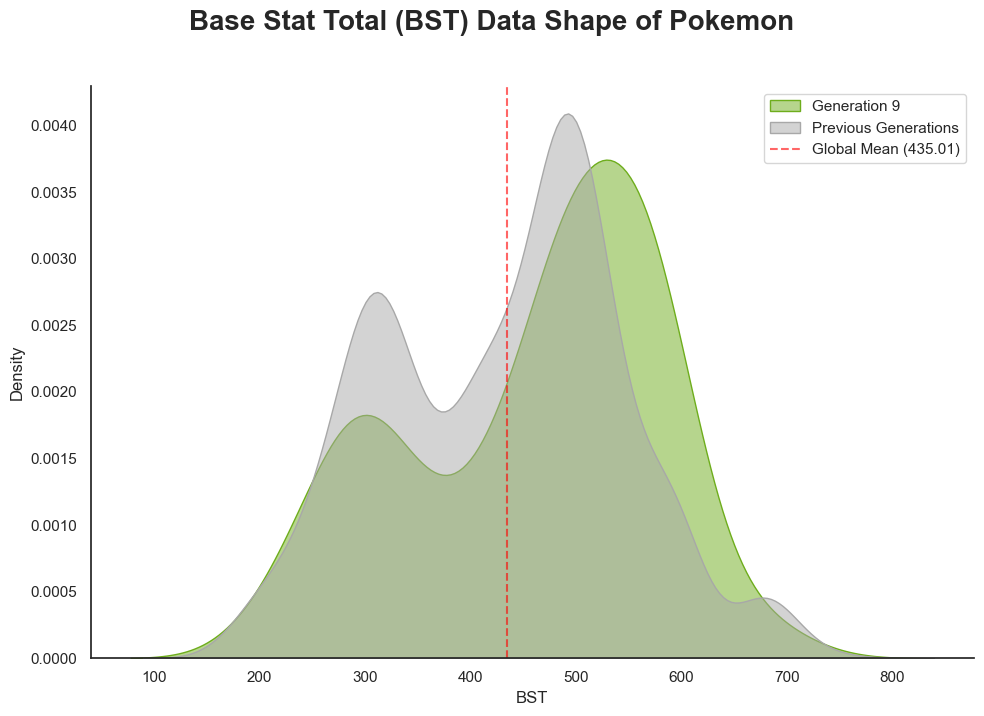

In [15]:
sns.set_theme(style="white")

# 1. Setup the figure
plt.figure(figsize=(10, 7))

# Define colors: gen 9 green vs a neutral grey for others
palette = {True: "#6ead1c", False: "#A8A8A8"}
labels = {True: "Generation 9", False: "Previous Generations"}

# --- Plot 1: KDE Distribution (The "Overlap" View) ---
for gen_9 in [True, False]:
    subset = df_powercreep_bst[df_powercreep_bst['from_gen_9'] == gen_9]
    sns.kdeplot(subset['bst'], fill=True,
                color=palette[gen_9], label=labels[gen_9], alpha=0.5)


global_mean = df_powercreep_bst['bst'].mean()
plt.axvline(global_mean, color='red', linestyle='--', alpha=0.6, label=f'Global Mean ({global_mean:.2f})')

plt.xlabel("BST")
plt.legend()

plt.suptitle("Base Stat Total (BST) Data Shape of Pokemon", fontsize=20, y=1.02, fontweight="bold")
plt.tight_layout()
sns.despine() # Remove top and right spines
plt.show()

## KDE Plot Analysis
As evidenced by the KDE plot, the BST distributions are not normally distributed. There are two peaks indicating a bimodal distribution. The first peak is likely non-evolved Pokémon it is expected for them to have a lower base stat total then their evolved counterparts. The second peak are fully evolved Pokémon as well as single stage Pokémon (they do not evolve from or evolve into any other Pokémon). The second peak is higher because in addition to fully evolved Pokémon (which have a corresponding pre-evolution in the smaller peak) there are single stage Pokémon. The second peak is the most relevant part of the data for this hypothesis as there are very few non-fully evolved Pokémon used in competitive play. My claim is visually supported as the second peak of the green distribution is to the right of the grey one.

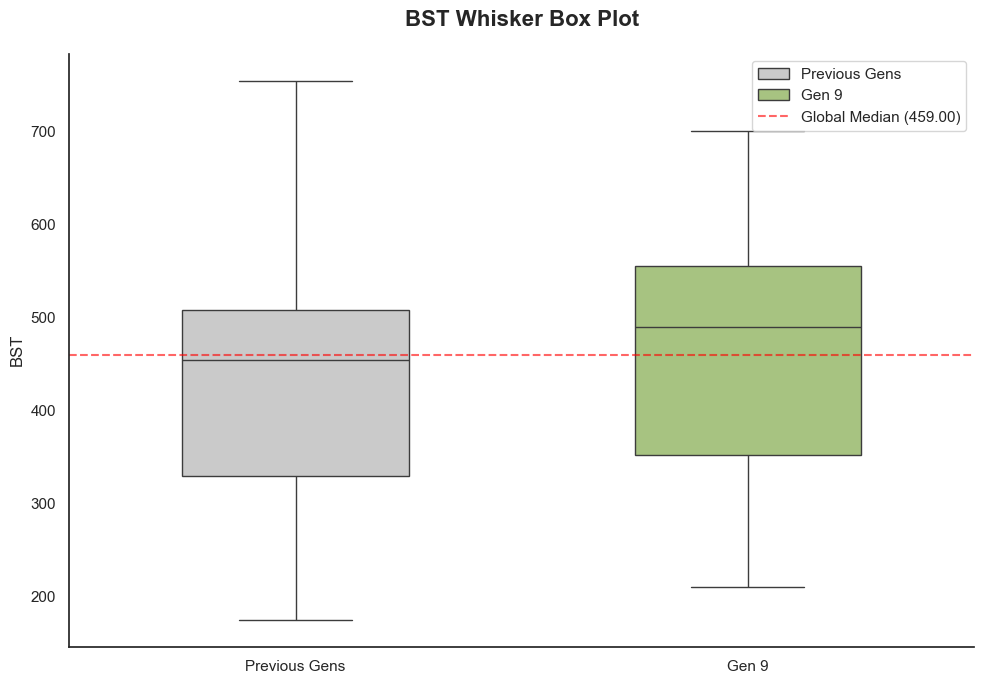

In [16]:
# 1. Prepare data (mapping booleans to strings to avoid palette errors)
plot_df = df_powercreep_bst.copy()
plot_df['Type Category'] = plot_df['from_gen_9'].map({True: 'Gen 9', False: 'Previous Gens'})

# 2. Define colors
palette = {'Gen 9': "#6ead1c", 'Previous Gens': "#A8A8A8"}

# 3. Setup the plot
plt.figure(figsize=(10, 7))

# Create the box plot
ax = sns.boxplot(
    data=plot_df,
    x='Type Category',
    y='bst',
    palette=palette,
    width=0.5,
    hue='Type Category',
    legend=True,
)

for patch in ax.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.6)) # Set alpha to 0.6

global_median = plot_df['bst'].median()
plt.axhline(global_median, color='red', linestyle='--', alpha=0.6, label=f'Global Median ({global_median:.2f})')

# Formatting
plt.title("BST Whisker Box Plot", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("BST", fontsize=12)
plt.xlabel("")
plt.legend(loc='upper right')

sns.despine() # Makes it look modern
plt.tight_layout()
plt.show()

## Box and Whisker Plot Analysis
To take a better look at how the data is spread, a whisker box plot was drawn. Again the alternative hypothesis is visually supported. Generation 9's median is significantly higher than the global median of 458 whereas previous generation's median is slightly below the global median. Interestingly the upper whisker of previous generations streches higher than that of generation 9 indicating previous generations have a select few Pokémon with higher BSTs despite having lower BSTs overall.

# Mann-Whitney U Test

As the data is non-normally distributed, Mann-Whitney U test was chosen because it makes no assumptions on the distribution of the data.

### **Hypotheses**

**Null Hypothesis ($H_0$):** The BST distribution of generation 9 Pokémon is the same as the BST distribution of previous generation Pokémon.

**Alternative Hypothesis ($H_1$):** The BST distribution of generation 9 Pokémon is stochastically higher than the BST distribution of previous generation Pokémon.

### **Results**

The calculated p-value is **0.0006** with a significance level of **0.05** we safely reject the null hypothesis. The results of the Mann-Whitney U test shows significant evidence in favor of my claim. It can be concluded that generation 9 Pokémon have a BST lead over Pokémon of previous generations thus proving the existence of powercreep.  

In [17]:
gen_9 = df_powercreep_bst[df_powercreep_bst['from_gen_9'] == True]['bst']
non_gen_9 = df_powercreep_bst[df_powercreep_bst['from_gen_9'] == False]['bst']

print(f"Gen 9 BST variance: {gen_9.var():.4f}")
print(f"Non gen 9 BST variance: {non_gen_9.var():.4f}")

Gen 9 BST variance: 13833.0164
Non gen 9 BST variance: 13041.1361


In [18]:
# Mann-Whitney U (Alternative: Gen_9 > Previous Gens)
u_stat, p_val_u = stats.mannwhitneyu(gen_9, non_gen_9, alternative='greater')

print(f"Mann-Whitney U test P-value: {p_val_u:.4f}")
if(p_val_u < 0.05):
  print(f"Null hypothesis rejected, generation 9 pokemon have a higher base stat total in general")
else:
  print(f"Failed to reject null hypothesis, generation 9 pokemon do not have a statistically significant base stat total advantage")

Mann-Whitney U test P-value: 0.0006
Null hypothesis rejected, generation 9 pokemon have a higher base stat total in general
